# Delay risk training (Colab Ready)

This notebook trains a **delay-risk classifier** (`delayRiskScore` and `delayRiskLabel`). ETA regression was removed from this notebook; the web contract may still include `predictedDeliveryDays` keys until a separate ETA pipeline is added.

Web integration contract target:
- Request shape follows `src/lib/forecast/types.ts` (`ForecastShipmentInput`)
- Response shape follows `ForecastPrediction` and `ForecastPredictResponse`


In [24]:
# Colab dependency setup
!pip -q install pandas scikit-learn joblib matplotlib seaborn lightgbm xgboost catboost


In [25]:
import inspect
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None

SEED = 111
np.random.seed(SEED)

DELAY_REFIT_METRIC = "f1_macro"
DELAY_SCORING = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "f1_macro": "f1_macro",
}


## Data Loading

### Option A: Upload a local CSV to Colab
- Put the file in `/content/`, then set `DATA_PATH`.

### Option B: Load from Google Drive
```python
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/path/to/shipments.csv'
```

Expected minimum columns (you can adapt names in the next cell):
- `OrderDate`, `ShipDate` (for ETA target)
- `ShipMode`, `OriginCountry`, `DestinationCountry`, `DistanceKm`, `Quantity`, `Sales`


In [26]:
try:
    import google.colab  # type: ignore
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Running in Colab: Google Drive mounted.')
else:
    print('Running outside Colab: skipping Google Drive mount.')


Running outside Colab: skipping Google Drive mount.


In [27]:
# Auto-detect dataset path for local (macOS) and Colab environments.
DATA_CANDIDATES = [
    '/Users/giahuy/Documents/GitHub/ISM/data/master_dataset.csv',
    '/Users/giahuy/Documents/GitHub/ISM/data/processed/master_dataset.csv',
    '/Users/giahuy/Documents/GitHub/ISM/master_dataset.csv',
    '/content/drive/My Drive/ISM/master_dataset.csv',
    '/content/master_dataset.csv',
]

DATA_PATH = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'Could not find dataset. Checked:\n' + '\n'.join(DATA_CANDIDATES)
    )

print(f'Using DATA_PATH: {DATA_PATH}')
master = pd.read_csv(DATA_PATH)
master['OrderDate'] = pd.to_datetime(master['OrderDate'], errors='coerce')
master = master.dropna(subset=['OrderDate', 'ShipStatus']).reset_index(drop=True)

# Non-time-series workflow: shuffle and split randomly.
master = master.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

train_idx, test_idx = train_test_split(
    np.arange(len(master)),
    test_size=0.20,
    random_state=SEED,
    shuffle=True,
    stratify=master['ShipStatus'],
)
train = master.iloc[train_idx].copy().reset_index(drop=True)
val = pd.DataFrame(columns=master.columns)
test = master.iloc[test_idx].copy().reset_index(drop=True)

print(f"master: {len(master):,} rows")
print(f"train (80% shuffled): {len(train):,} rows")
print(f"test (20% shuffled): {len(test):,} rows")

Using DATA_PATH: /Users/giahuy/Documents/GitHub/ISM/data/master_dataset.csv
master: 9,994 rows
train (80% shuffled): 7,995 rows
test (20% shuffled): 1,999 rows


In [28]:
train.columns

Index(['RetailOrderID', 'OrderID', 'OrderDate', 'ShipDate', 'ShipModeID',
       'CustomerID', 'PostalCode', 'RetailSalesPeopleID', 'ProductID',
       'Returned', 'ShipStatus', 'Sales', 'Quantity', 'Profit', 'Cost', 'Days',
       'CusSegmentID', 'CustomerName', 'Segment', 'ProductName',
       'SubCategoryID', 'UnitCP', 'UnitSP', 'SubCategory', 'CategoryID',
       'Category', 'ShipMode', 'Country', 'Region', 'State', 'City',
       'longitude', 'latitude', 'RetailSalesPeople', 'year', 'month'],
      dtype='object')

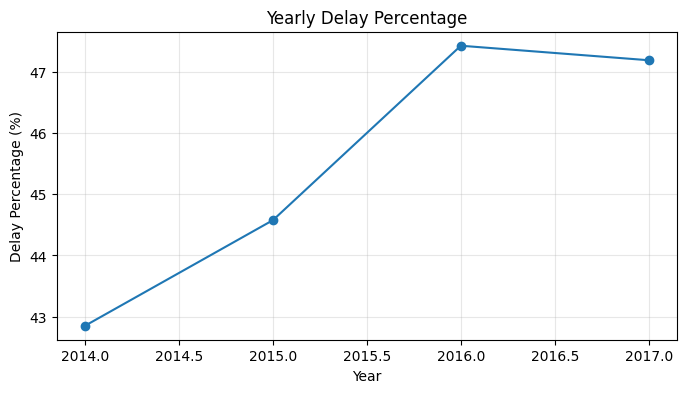

   year   delayPct
0  2014  42.849975
1  2015  44.576594
2  2016  47.429455
3  2017  47.192029


In [29]:
# Plot yearly delay percentage before feature engineering drops orderDate.
import matplotlib.pyplot as plt

_delay_yearly = master.copy()
_delay_yearly["OrderDate"] = pd.to_datetime(_delay_yearly["OrderDate"], errors="coerce")
_delay_yearly = _delay_yearly.dropna(subset=["OrderDate", "ShipStatus"])
_delay_yearly["isDelayed"] = (_delay_yearly["ShipStatus"] == "Late").astype(float)

yearly_delay_pct = (
    _delay_yearly.groupby(_delay_yearly["OrderDate"].dt.year)["isDelayed"]
    .mean()
    .mul(100)
    .reset_index(name="delayPct")
    .rename(columns={"OrderDate": "year"})
)

plt.figure(figsize=(8, 4))
plt.plot(yearly_delay_pct["year"], yearly_delay_pct["delayPct"], marker="o")
plt.title("Yearly Delay Percentage")
plt.xlabel("Year")
plt.ylabel("Delay Percentage (%)")
plt.grid(True, alpha=0.3)
plt.show()

print(yearly_delay_pct)


In [30]:
# Adjust mapping to match the actual dataset columns.
column_map = {
    'RetailOrderID': 'retailOrderID',
    'OrderID': 'orderID',
    'OrderDate': 'orderDate',
    'ShipDate': 'shipDate',
    'ShipModeID': 'shipModeID',
    'CustomerID': 'customerID',
    'PostalCode': 'postalCode',
    'RetailSalesPeopleID': 'retailSalesPeopleID',
    'ProductID': 'productID',
    'Returned': 'returned',
    'ShipStatus': 'shipStatus',
    'Sales': 'sales',
    'Quantity': 'quantity',
    'Profit': 'profit',
    'Cost': 'cost',
    'Days': 'days',
    'CusSegmentID': 'cusSegmentID',
    'CustomerName': 'customerName',
    'Segment': 'segment',
    'ProductName': 'productName',
    'SubCategoryID': 'subCategoryID',
    'UnitCP': 'unitCP',
    'UnitSP': 'unitSP',
    'SubCategory': 'subCategory',
    'CategoryID': 'categoryID',
    'Category': 'category',
    'ShipMode': 'shipMode',
    'Country': 'country',
    'Region': 'region',
    'State': 'state',
    'City': 'city',
    'longitude': 'longitude',
    'latitude': 'latitude',
    'RetailSalesPeople': 'retailSalesPeople',
    'year': 'year',
    'month': 'month'
}

def clean_dates(df_input):
    df_out = df_input.copy()
    # Apply the column rename map first
    df_out = df_out.rename(columns=column_map)

    # Now access the properly named columns
    df_out['orderDate'] = pd.to_datetime(df_out['orderDate'], errors='coerce')
    df_out['shipDate'] = pd.to_datetime(df_out['shipDate'], errors='coerce')
    df_out['dayOfWeek'] = df_out['orderDate'].dt.day_name()
    df_out['dayOfMonth'] = df_out['orderDate'].dt.day
    df_out['isWeekend'] = df_out['orderDate'].dt.dayofweek.isin([5, 6]).astype(int)
    df_out = df_out.dropna(subset=['orderDate', 'shipDate', 'shipMode'])
    return df_out.drop(columns=['orderDate'], errors='ignore')

train = clean_dates(train)
test = clean_dates(test)
val = clean_dates(val)


In [31]:
cols_to_drop = ['retailOrderID', 'orderID', 'customerID', 'returned', 'customerName', 'returned', 'retailSalesPeople','customerName', 'category', 'country','state', 'city','productName', 'shipDate']

train = train.drop(columns=cols_to_drop, errors='ignore')
test = test.drop(columns=cols_to_drop, errors='ignore')
val = val.drop(columns=cols_to_drop, errors='ignore')

print("Columns dropped successfully.")


Columns dropped successfully.


In [32]:
import pandas as pd
import numpy as np

# Select numerical columns
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# Exclude geographical columns and any ID columns
geo_cols = ['longitude', 'latitude', 'postalCode']
cols_to_examine = [col for col in num_cols if col not in geo_cols and 'id' not in col.lower()]

# Calculate mean, median, and IQR
stats = []
for col in cols_to_examine:
    mean_val = train[col].mean()
    median_val = train[col].median()
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr_val = q3 - q1

    stats.append({
        'Feature': col,
        'Mean': mean_val,
        'Median': median_val,
        'IQR': iqr_val
    })

stats_df = pd.DataFrame(stats)
display(stats_df)


,Feature,Mean,Median,IQR
0,sales,232.777624,55.1040,194.47200
1,quantity,3.798249,3.0000,3.00000
2,profit,28.466301,8.7672,28.00100
3,cost,204.311323,41.8824,170.93115
4,days,34.809631,4.0000,59.00000
5,unitCP,54.081600,13.1043,52.52080
6,unitSP,61.212806,16.4800,58.38600
7,year,2015.728330,2016.0000,2.00000
8,month,7.191495,8.0000,6.00000
9,dayOfMonth,16.070544,15.0000,13.00000


## Insights:
 - The average sales are around 227\$ and the average cost is around 200\$. This confirms that the profit margin is relatively low for the current period.
- The unitCP averaging about 53\$, meanwhile unitSP is round 60\$. This shows that the differnce between the cost and the sell price are not large enough.

In [33]:
import pandas as pd


print("\nCross-tabulation: Region vs Segment")
ct2 = pd.crosstab(train['region'], train['segment'])
display(ct2)

if 'shipStatus' in train.columns:
    print("\nCross-tabulation: Ship Status vs Ship Mode")
    ct3 = pd.crosstab(train['shipStatus'], train['shipMode'])
    display(ct3)



Cross-tabulation: Region vs Segment


segment,Consumer,Corporate,Home Office
region,,,
Central,969,544,365
East,1163,698,394
South,668,422,217
West,1334,767,454



Cross-tabulation: Ship Status vs Ship Mode


shipMode,First Class,Same Day,Second Class,Standard Class
shipStatus,,,,
Late,705,11,811,2138
On-Time,510,423,739,2658


--- Correlation for Numeric Values ---


,sales,quantity,profit,cost,days,unitCP,unitSP,year,month,dayOfMonth,isWeekend
sales,1.000000,0.199858,0.423710,0.929383,-0.014597,0.839488,0.838637,-0.012453,-0.002488,0.010824,-0.019002
quantity,0.199858,1.000000,0.069502,0.191931,0.000782,-0.000880,-0.005375,-0.004212,0.007689,0.024811,-0.000632
profit,0.423710,0.069502,1.000000,0.059443,-0.010090,0.076041,0.272014,0.005687,-0.005559,0.011513,-0.005279
cost,0.929383,0.191931,0.059443,1.000000,-0.011975,0.894168,0.813371,-0.016041,-0.000477,0.007237,-0.018790
days,-0.014597,0.000782,-0.010090,-0.011975,1.000000,-0.009850,-0.009476,-0.003049,-0.426413,-0.511735,-0.026164
unitCP,0.839488,-0.000880,0.076041,0.894168,-0.009850,1.000000,0.926203,-0.003269,0.000093,-0.000473,-0.019179
unitSP,0.838637,-0.005375,0.272014,0.813371,-0.009476,0.926203,1.000000,-0.001584,-0.000974,0.001184,-0.017432
year,-0.012453,-0.004212,0.005687,-0.016041,-0.003049,-0.003269,-0.001584,1.000000,-0.044936,-0.011807,0.005630
month,-0.002488,0.007689,-0.005559,-0.000477,-0.426413,0.000093,-0.000974,-0.044936,1.000000,0.152208,-0.020312
dayOfMonth,0.010824,0.024811,0.011513,0.007237,-0.511735,-0.000473,0.001184,-0.011807,0.152208,1.000000,0.033597


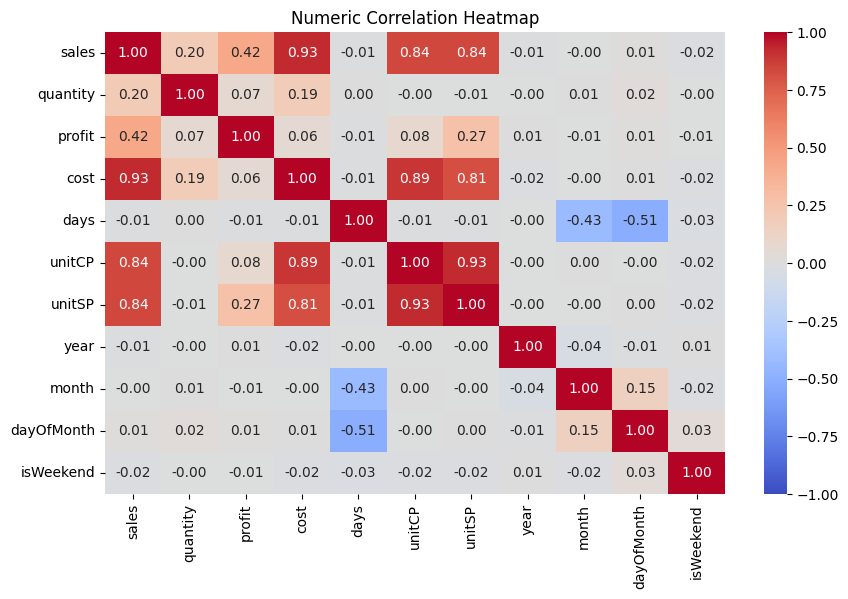


--- Chi-Square Test for Categorical Values ---
Selected Categorical Features for Chi-Square: ['shipStatus', 'segment', 'subCategory', 'shipMode', 'region', 'dayOfWeek']



,Feature 1,Feature 2,Chi2 Statistic,p-value
0,shipStatus,shipMode,429.797155,7.768059e-93
1,shipStatus,dayOfWeek,72.290534,1.384846e-13
2,segment,dayOfWeek,41.463877,4.097904e-05
3,segment,shipMode,28.210249,8.577094e-05
4,region,dayOfWeek,35.754280,7.585243e-03
5,segment,subCategory,45.922132,5.281850e-02
6,shipMode,region,16.633788,5.476936e-02
7,shipMode,dayOfWeek,28.019581,6.175784e-02
8,shipStatus,region,6.890181,7.548169e-02
9,subCategory,dayOfWeek,111.999566,1.263908e-01


In [34]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

# --- 1. Correlation for Numeric Values ---
print("--- Correlation for Numeric Values ---")
# Identify numeric columns, excluding geo and ID columns
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
geo_id_cols = ['longitude', 'latitude', 'postalCode']
numeric_features = [c for c in num_cols if c not in geo_id_cols and 'id' not in c.lower()]

corr_matrix = train[numeric_features].corr()
display(corr_matrix)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Numeric Correlation Heatmap")
plt.show()

# --- 2. Chi-Square for Categorical Values ---
print("\n--- Chi-Square Test for Categorical Values ---")
cat_cols = train.select_dtypes(include=['object', 'category']).columns.tolist()

# Filter out columns with too many unique values to avoid noise (e.g. customer names, high-cardinality IDs)
cat_features = [c for c in cat_cols if train[c].nunique() < 20]
print(f"Selected Categorical Features for Chi-Square: {cat_features}\n")

# Calculate pairwise Chi-Square for selected categorical variables
chi2_results = []
for col1, col2 in itertools.combinations(cat_features, 2):
    contingency = pd.crosstab(train[col1], train[col2])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi2_results.append({
        'Feature 1': col1,
        'Feature 2': col2,
        'Chi2 Statistic': chi2,
        'p-value': p
    })

chi2_df = pd.DataFrame(chi2_results)
# Sort by p-value (lowest p-value means strong evidence of dependency)
chi2_df = chi2_df.sort_values(by='p-value').reset_index(drop=True)
display(chi2_df)


### Chi-Square Results Interpretation

Based on the p-values from the Chi-Square test, we can determine the statistical independence of our categorical variables. A lower p-value indicates a stronger dependency between the two features.

1. **Perfect / Very Strong Dependencies (p-value ≈ 0)**:
   - **`subCategory` & `category`**: Naturally, a subcategory is strictly tied to its parent category.
   - **`region` & `retailSalesPeople`**: Salespeople are assigned to specific regions, making these two variables highly dependent.
   - **`shipStatus` & `shipMode`**: The mode of shipment (e.g., Same Day, Standard) is a massive factor in determining whether a shipment is on time or late.

2. **Statistically Significant Dependencies (p-value < 0.05)**:
   - **`segment` & `shipMode`**: Different customer segments (e.g., Corporate vs. Consumer) might prefer or require different shipping modes.
   - **`shipStatus` & `region` / `retailSalesPeople`**: Shipping delays might be more frequent in certain geographic regions.

3. **No Dependency (p-value = 1.0)**:
   - Any pairing involving **`country`** yields a p-value of 1.0. This happens because the dataset likely only contains data for a single country (e.g., United States). With zero variance, it cannot be statistically dependent on any other feature.

In [35]:
cols_to_drop_mc = ['unitCP', 'unitSP','cost', 'subCategory','year']

train = train.drop(columns=cols_to_drop_mc, errors='ignore')
test = test.drop(columns=cols_to_drop_mc, errors='ignore')
val = val.drop(columns=cols_to_drop_mc, errors='ignore')

print(f"Dropped columns to avoid multicollinearity: {cols_to_drop_mc}")

Dropped columns to avoid multicollinearity: ['unitCP', 'unitSP', 'cost', 'subCategory', 'year']


--- Correlation for Numeric Values ---


,sales,quantity,profit,days,month,dayOfMonth,isWeekend
sales,1.000000,0.199858,0.423710,-0.014597,-0.002488,0.010824,-0.019002
quantity,0.199858,1.000000,0.069502,0.000782,0.007689,0.024811,-0.000632
profit,0.423710,0.069502,1.000000,-0.010090,-0.005559,0.011513,-0.005279
days,-0.014597,0.000782,-0.010090,1.000000,-0.426413,-0.511735,-0.026164
month,-0.002488,0.007689,-0.005559,-0.426413,1.000000,0.152208,-0.020312
dayOfMonth,0.010824,0.024811,0.011513,-0.511735,0.152208,1.000000,0.033597
isWeekend,-0.019002,-0.000632,-0.005279,-0.026164,-0.020312,0.033597,1.000000


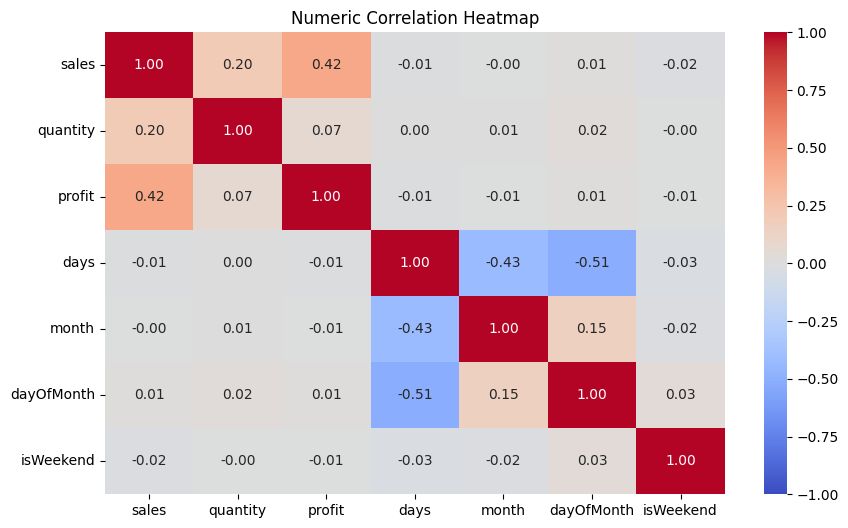

In [36]:
# --- 1. Correlation for Numeric Values ---
print("--- Correlation for Numeric Values ---")
# Identify numeric columns, excluding geo and ID columns
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
geo_id_cols = ['longitude', 'latitude', 'postalCode']
numeric_features = [c for c in num_cols if c not in geo_id_cols and 'id' not in c.lower()]

corr_matrix = train[numeric_features].corr()
display(corr_matrix)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Numeric Correlation Heatmap")
plt.show()

In [37]:
# Delay prediction dataset: target is shipStatus; drop realized transit (days)
print("Preparing delay prediction datasets...")
X_train_delay = train.drop(columns=["shipStatus", "days"], errors="ignore")
y_train_delay = train["shipStatus"]

X_val_delay = pd.DataFrame(columns=X_train_delay.columns)
y_val_delay = pd.Series(dtype=y_train_delay.dtype)

X_test_delay = test.drop(columns=["shipStatus", "days"], errors="ignore")
y_test_delay = test["shipStatus"]

DELAY_LABEL_MAP = {"On-Time": 0, "Late": 1}
DELAY_LABEL_INV_MAP = {v: k for k, v in DELAY_LABEL_MAP.items()}

y_train_delay_bin = y_train_delay.map(DELAY_LABEL_MAP)
y_val_delay_bin = y_val_delay.map(DELAY_LABEL_MAP)
y_test_delay_bin = y_test_delay.map(DELAY_LABEL_MAP)

if y_train_delay_bin.isna().any() or y_val_delay_bin.isna().any() or y_test_delay_bin.isna().any():
    raise ValueError("Unexpected shipStatus value found. Expected only: 'On-Time' and 'Late'.")

print(f"Delay training features shape: {X_train_delay.shape}, target shape: {y_train_delay.shape}")
print("Delay label mapping:", DELAY_LABEL_MAP)


Preparing delay prediction datasets...
Delay training features shape: (7995, 19), target shape: (7995,)
Delay label mapping: {'On-Time': 0, 'Late': 1}


In [38]:
# -------------------------------------------------------
# Model registries, preprocessing helper, and subsampling
# -------------------------------------------------------

_pos_ct = int((y_train_delay_bin == 1).sum())
_neg_ct = int((y_train_delay_bin == 0).sum())
_xgb_scale_pos_weight = float(_neg_ct / max(_pos_ct, 1))

delay_models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        random_state=SEED,
        class_weight="balanced",
    ),
    "HistGradientBoostingClassifier": HistGradientBoostingClassifier(
        random_state=SEED,
        class_weight="balanced",
    ),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced",
    ),
    "DecisionTreeClassifier": DecisionTreeClassifier(
        random_state=SEED,
        class_weight="balanced",
    ),
    "MLPClassifier": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size="auto",
        learning_rate="adaptive",
        max_iter=500,
        early_stopping=False,
        random_state=SEED,
    ),
}

if LGBMClassifier is not None:
    delay_models["LGBMClassifier"] = LGBMClassifier(
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
        class_weight="balanced",
    )
else:
    print("lightgbm not available: skipping LGBMClassifier")

if XGBClassifier is not None:
    delay_models["XGBClassifier"] = XGBClassifier(
        random_state=SEED,
        n_jobs=-1,
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=_xgb_scale_pos_weight,
    )
else:
    print("xgboost not available: skipping XGBClassifier")

if CatBoostClassifier is not None:
    delay_models["CatBoostClassifier"] = CatBoostClassifier(
        random_seed=SEED,
        verbose=False,
        auto_class_weights="Balanced",
        allow_writing_files=False,
    )
else:
    print("catboost not available: skipping CatBoostClassifier")

PARAM_GRIDS = {
    "LogisticRegression": {
        "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        "model__solver": ["lbfgs", "saga"],
    },
    "HistGradientBoostingClassifier": {
        "model__max_iter": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_leaf": [10, 20, 40],
        "model__l2_regularization": [0.0, 0.1, 1.0],
    },
    "RandomForestClassifier": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
    },
    "DecisionTreeClassifier": {
        "model__max_depth": [None, 5, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
    },
    "MLPClassifier": {
        "model__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64), (256, 128)],
        "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
        "model__learning_rate_init": [1e-3, 5e-4, 1e-4],
    },
    "LGBMClassifier": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__num_leaves": [31, 63, 127],
        "model__max_depth": [-1, 8, 12],
        "model__min_child_samples": [10, 20, 50],
    },
    "XGBClassifier": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.7, 0.85, 1.0],
    },
    "CatBoostClassifier": {
        "model__iterations": [100, 200, 300],
        "model__depth": [4, 6, 8],
        "model__learning_rate": [0.03, 0.05, 0.1],
    },
}


def build_model_pipeline(X_frame, estimator):
    numeric_features = X_frame.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    id_numeric_features = [c for c in numeric_features if "id" in c.lower()]
    month_passthrough_features = [c for c in numeric_features if c.lower() == "month"]
    # Include dayOfMonth and isWeekend in passthrough for normalization
    dayofmonth_passthrough_features = [c for c in numeric_features if c.lower() == "dayofmonth"]
    isweekend_passthrough_features = [c for c in numeric_features if c.lower() == "isweekend"]
    passthrough_numeric_features = (
        id_numeric_features +
        month_passthrough_features +
        dayofmonth_passthrough_features +
        isweekend_passthrough_features
    )
    scaled_numeric_features = [c for c in numeric_features if c not in passthrough_numeric_features]
    categorical_features = [c for c in X_frame.columns if c not in numeric_features]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num_scaled",
                Pipeline(steps=[("scaler", StandardScaler())]),
                scaled_numeric_features,
            ),
            (
                "num_passthrough",
                "passthrough",
                passthrough_numeric_features,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                    ]
                ),
                categorical_features,
            ),
        ]
    )

    return Pipeline(steps=[("preprocessor", preprocessor), ("model", estimator)])


def random_subset(X_df, y_sr, frac=0.30):
    X_sub, _, y_sub, _ = train_test_split(
        X_df,
        y_sr,
        train_size=frac,
        random_state=SEED,
        shuffle=True,
        stratify=y_sr,
    )
    return X_sub.reset_index(drop=True), y_sub.reset_index(drop=True)


X_tune_delay, y_tune_delay = random_subset(X_train_delay, y_train_delay_bin, frac=0.30)

print(f"Full delay train : {X_train_delay.shape[0]} rows")
print(f"Delay tune subset: {X_tune_delay.shape[0]} rows (random 30%)")

CKPT_DIR = "/content/artifacts/checkpoints" if IS_COLAB else os.path.join(os.getcwd(), "artifacts", "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Checkpoint dir: {CKPT_DIR}")


Full delay train : 7995 rows
Delay tune subset: 2398 rows (random 30%)
Checkpoint dir: /Users/giahuy/Documents/GitHub/ISM/notebooks/artifacts/checkpoints


In [39]:
# -------------------------------------------------------
# Step 1: Delay model selection on shuffled holdout
# -------------------------------------------------------

def _holdout_split(X_df, y_sr, val_frac=0.30):
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_df,
        y_sr,
        test_size=val_frac,
        random_state=SEED,
        shuffle=True,
        stratify=y_sr,
    )
    return X_tr.reset_index(drop=True), X_va.reset_index(drop=True), y_tr.reset_index(drop=True), y_va.reset_index(drop=True)


def _fit_delay_pipe(pipe, X, y, model_name):
    # MLPClassifier only supports sample_weight in newer sklearn; Colab may omit it.
    est = pipe.named_steps["model"]
    if model_name == "MLPClassifier" and "sample_weight" in inspect.signature(est.__class__.fit).parameters:
        sw = compute_sample_weight("balanced", y)
        pipe.fit(X, y, model__sample_weight=sw)
    else:
        pipe.fit(X, y)


print("Step 1 - Delay model selection (shuffled 70/30 holdout on 30% tuning subset)...")
X_tr_sel_d, X_va_sel_d, y_tr_sel_d, y_va_sel_d = _holdout_split(X_tune_delay, y_tune_delay)

delay_rows = []
for model_name, model in delay_models.items():
    pipe = build_model_pipeline(X_tr_sel_d, clone(model))
    _fit_delay_pipe(pipe, X_tr_sel_d, y_tr_sel_d, model_name)
    pred = pipe.predict(X_va_sel_d)
    proba = pipe.predict_proba(X_va_sel_d)[:, 1] if hasattr(pipe, "predict_proba") else pred.astype(float)
    roc = roc_auc_score(y_va_sel_d, proba)
    pr_auc = average_precision_score(y_va_sel_d, proba)
    f1m = f1_score(y_va_sel_d, pred, average="macro")
    acc = accuracy_score(y_va_sel_d, pred)
    delay_rows.append(
        {
            "model": model_name,
            "holdout_roc_auc": roc,
            "holdout_pr_auc": pr_auc,
            "holdout_f1_macro": f1m,
            "holdout_accuracy": acc,
        }
    )
    print(
        f"  {model_name}: ROC-AUC={roc:.4f} PR-AUC={pr_auc:.4f} F1-macro={f1m:.4f} Accuracy={acc:.4f}"
    )

delay_cv_results = (
    pd.DataFrame(delay_rows)
    .sort_values(["holdout_f1_macro", "holdout_pr_auc", "holdout_roc_auc"], ascending=False)
    .reset_index(drop=True)
)
print("\nDelay model selection results (shuffled holdout):")
print(delay_cv_results)

delay_best_model_name = delay_cv_results.loc[0, "model"]
print(f"\nSelected delay model: {delay_best_model_name}")

stage1_checkpoint = {
    "delay_cv_results": delay_cv_results,
    "delay_best_model_name": delay_best_model_name,
}
joblib.dump(stage1_checkpoint, f"{CKPT_DIR}/stage1_model_selection.pkl")
print("Saved checkpoint: stage1_model_selection.pkl")


Step 1 - Delay model selection (shuffled 70/30 holdout on 30% tuning subset)...
  LogisticRegression: ROC-AUC=0.7880 PR-AUC=0.7727 F1-macro=0.7170 Accuracy=0.7181
  HistGradientBoostingClassifier: ROC-AUC=0.9135 PR-AUC=0.9176 F1-macro=0.8280 Accuracy=0.8306
  RandomForestClassifier: ROC-AUC=0.8791 PR-AUC=0.8892 F1-macro=0.8168 Accuracy=0.8208
  DecisionTreeClassifier: ROC-AUC=0.7966 PR-AUC=0.7105 F1-macro=0.7970 Accuracy=0.7986
  MLPClassifier: ROC-AUC=0.7652 PR-AUC=0.7438 F1-macro=0.6887 Accuracy=0.6903


/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LGBMClassifier: ROC-AUC=0.9099 PR-AUC=0.9152 F1-macro=0.8162 Accuracy=0.8181
  XGBClassifier: ROC-AUC=0.9084 PR-AUC=0.9134 F1-macro=0.8280 Accuracy=0.8306
  CatBoostClassifier: ROC-AUC=0.8992 PR-AUC=0.9061 F1-macro=0.8121 Accuracy=0.8167

Delay model selection results (shuffled holdout):
                            model  holdout_roc_auc  holdout_pr_auc  \
0  HistGradientBoostingClassifier         0.913543        0.917614   
1                   XGBClassifier         0.908376        0.913354   
2          RandomForestClassifier         0.879087        0.889179   
3                  LGBMClassifier         0.909891        0.915177   
4              CatBoostClassifier         0.899223        0.906083   
5          DecisionTreeClassifier         0.796620        0.710460   
6              LogisticRegression         0.787980        0.772689   
7                   MLPClassifier         0.765183        0.743765   

   holdout_f1_macro  holdout_accuracy  
0          0.827986          0.830556 

In [40]:
# -------------------------------------------------------
# Step 2: RandomizedSearchCV with shuffled 5-fold CV on random subset
# -------------------------------------------------------

def tune_model(model_name, base_estimator, X_tune, y_tune, scoring, refit_metric):
    param_grid = PARAM_GRIDS.get(model_name, {})
    pipeline = build_model_pipeline(X_tune, clone(base_estimator))

    if not param_grid:
        print(f"  {model_name}: no hyperparameters to tune - using defaults.")
        return {}

    cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    print(f"  {model_name}: tuning with {cv_splitter.get_n_splits()} shuffled stratified fold(s).")

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=15,
        cv=cv_splitter,
        scoring=scoring,
        refit=refit_metric,
        n_jobs=-1,
        random_state=SEED,
        error_score="raise",
    )
    fit_kw = {}
    m = pipeline.named_steps["model"]
    if model_name == "MLPClassifier" and "sample_weight" in inspect.signature(m.__class__.fit).parameters:
        fit_kw["model__sample_weight"] = compute_sample_weight("balanced", y_tune)
    search.fit(X_tune, y_tune, **fit_kw)

    best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
    print(f"  {model_name}: best params = {best_params}")
    return best_params


X_tune10_delay, y_tune10_delay = random_subset(X_train_delay, y_train_delay_bin, frac=0.30)
delay_frac = len(X_tune10_delay) / max(len(X_train_delay), 1)

print(f"Delay tuning subset: {len(X_tune10_delay):,} rows ({delay_frac*100:.0f}%, shuffled)")
print("\nTuning delay model with shuffled 5-fold stratified CV on 30% subset...")
delay_best_params = tune_model(
    delay_best_model_name,
    delay_models[delay_best_model_name],
    X_tune10_delay,
    y_tune10_delay,
    scoring=DELAY_SCORING,
    refit_metric=DELAY_REFIT_METRIC,
)

stage2_checkpoint = {
    "delay_best_model_name": delay_best_model_name,
    "delay_best_params": delay_best_params,
}
joblib.dump(stage2_checkpoint, f"{CKPT_DIR}/stage2_tuning.pkl")
print("Saved checkpoint: stage2_tuning.pkl")


Delay tuning subset: 2,398 rows (30%, shuffled)

Tuning delay model with shuffled 5-fold stratified CV on 30% subset...
  HistGradientBoostingClassifier: tuning with 5 shuffled stratified fold(s).
  HistGradientBoostingClassifier: best params = {'min_samples_leaf': 20, 'max_iter': 100, 'max_depth': 5, 'learning_rate': 0.1, 'l2_regularization': 1.0}
Saved checkpoint: stage2_tuning.pkl


In [41]:
# -------------------------------------------------------
# Step 3: Fit base pipeline on full train, then sigmoid calibration (FrozenEstimator)
# -------------------------------------------------------

def build_tuned_estimator(base_estimator, best_params):
    estimator = clone(base_estimator)
    if best_params:
        estimator.set_params(**best_params)
    return estimator


print("Fitting delay base pipeline on full training set with tuned params...")
delay_tuned_estimator = build_tuned_estimator(delay_models[delay_best_model_name], delay_best_params)
delay_base_pipeline = build_model_pipeline(X_train_delay, delay_tuned_estimator)
_fit_delay_pipe(delay_base_pipeline, X_train_delay, y_train_delay_bin, delay_best_model_name)

_, X_cal, _, y_cal = train_test_split(
    X_train_delay,
    y_train_delay_bin,
    test_size=0.15,
    random_state=SEED,
    shuffle=True,
    stratify=y_train_delay_bin,
)

print(f"Calibration fit on random 15% split: {len(X_cal)} rows ({len(X_cal) / len(X_train_delay):.1%} of train)")

delay_cal = CalibratedClassifierCV(
    FrozenEstimator(delay_base_pipeline), method="sigmoid", cv=None
)
delay_cal.fit(X_cal, y_cal)

delay_test_prob = delay_cal.predict_proba(X_test_delay)[:, 1]
delay_test_pred = (delay_test_prob >= 0.5).astype(int)
delay_test_pred_label = pd.Series(delay_test_pred).map(DELAY_LABEL_INV_MAP)
delay_test_auc = roc_auc_score(y_test_delay_bin, delay_test_prob)
delay_test_pr_auc = average_precision_score(y_test_delay_bin, delay_test_prob)
delay_test_f1 = f1_score(y_test_delay_bin, delay_test_pred, average="macro", zero_division=0)
delay_test_accuracy = accuracy_score(y_test_delay_bin, delay_test_pred)
delay_test_brier = brier_score_loss(y_test_delay_bin, delay_test_prob)

print(f"Delay model  : {delay_best_model_name} (calibrated sigmoid / FrozenEstimator)")
print(f"Tuned params : {delay_best_params}")
print(f"Holdout ROC-AUC : {delay_test_auc:.4f}")
print(f"Holdout PR-AUC  : {delay_test_pr_auc:.4f}")
print(f"Holdout F1-macro: {delay_test_f1:.4f}")
print(f"Holdout Accuracy: {delay_test_accuracy:.4f}")
print(f"Holdout Brier   : {delay_test_brier:.4f}")

feature_importance_path = None
try:
    preprocessor = delay_base_pipeline.named_steps["preprocessor"]
    model = delay_base_pipeline.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()

    if hasattr(model, "feature_importances_"):
        importance_values = np.asarray(model.feature_importances_).ravel()
    elif hasattr(model, "coef_"):
        coef = np.asarray(model.coef_)
        importance_values = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef).ravel()
    else:
        importance_values = None

    if importance_values is not None and len(importance_values) == len(feature_names):
        feature_importance_df = (
            pd.DataFrame({"feature": feature_names, "importance": importance_values})
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )
        feature_importance_path = f"{CKPT_DIR}/delay_feature_importance.csv"
        feature_importance_df.to_csv(feature_importance_path, index=False)
        print("Top 20 feature importances:")
        print(feature_importance_df.head(20))
    else:
        print("Feature importance report skipped: unsupported model output shape.")
except Exception as e:
    print(f"Feature importance report skipped: {e}")

stage3_checkpoint = {
    "delay_calibrated_model": delay_cal,
    "feature_importance_path": feature_importance_path,
    "metrics": {
        "delay_test_auc": float(delay_test_auc),
        "delay_test_pr_auc": float(delay_test_pr_auc),
        "delay_test_f1_macro": float(delay_test_f1),
        "delay_test_accuracy": float(delay_test_accuracy),
        "delay_test_brier": float(delay_test_brier),
    },
}
joblib.dump(stage3_checkpoint, f"{CKPT_DIR}/stage3_final_models.pkl")
print("Saved checkpoint: stage3_final_models.pkl")


Fitting delay base pipeline on full training set with tuned params...
Calibration fit on random 15% split: 1200 rows (15.0% of train)
Delay model  : HistGradientBoostingClassifier (calibrated sigmoid / FrozenEstimator)
Tuned params : {'min_samples_leaf': 20, 'max_iter': 100, 'max_depth': 5, 'learning_rate': 0.1, 'l2_regularization': 1.0}
Holdout ROC-AUC : 0.9173
Holdout PR-AUC  : 0.9225
Holdout F1-macro: 0.8250
Holdout Accuracy: 0.8284
Holdout Brier   : 0.1137
Feature importance report skipped: unsupported model output shape.
Saved checkpoint: stage3_final_models.pkl


In [42]:
# Final evaluation summary and classification report
auto_delay_label = np.where(
    delay_test_prob >= 0.6,
    "High",
    np.where(delay_test_prob >= 0.3, "Medium", "Low"),
)

print("=== Final holdout evaluation (shuffled 20% test split) ===")
print(f"Delay model         : {delay_best_model_name}")
print(f"CV refit metric     : {DELAY_REFIT_METRIC}")
print(f"Calibration         : sigmoid (FrozenEstimator, random 15% of train)")
print(f"Delay ROC-AUC       : {delay_test_auc:.3f}")
print(f"Delay PR-AUC        : {delay_test_pr_auc:.3f}")
print(f"Delay F1 (macro)    : {delay_test_f1:.3f}")
print(f"Delay accuracy      : {delay_test_accuracy:.3f}")
print(f"Delay Brier score   : {delay_test_brier:.3f}")
print(classification_report(y_test_delay, delay_test_pred_label, zero_division=0))

ARTIFACT_DIR = "/content/artifacts" if IS_COLAB else os.path.join(os.getcwd(), "artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)
joblib.dump(delay_cal, os.path.join(ARTIFACT_DIR, "delay_classifier.pkl"))

artifact_metadata = {
    "modelVersion": "delay-calibrated-v1",
    "features": {
        "delay": list(X_train_delay.columns),
    },
    "targets": ["is_delayed"],
    "delayLabelMap": DELAY_LABEL_MAP,
    "delayRefitMetric": DELAY_REFIT_METRIC,
    "calibrationMethod": "sigmoid_frozen_estimator_random15pct",
    "tuningSubsampleSize": int(X_tune10_delay.shape[0]),
    "tuningSubsampleFraction": float(delay_frac),
    "bestModels": {
        "delay": delay_best_model_name,
    },
    "tunedParams": {
        "delay": delay_best_params,
    },
    "featureImportance": {
        "delay": feature_importance_path,
    },
    "cvSummary": {
        "delay": delay_cv_results.to_dict(orient="records"),
    },
    "holdoutMetrics": {
        "delay_auc": float(delay_test_auc),
        "delay_pr_auc": float(delay_test_pr_auc),
        "delay_f1_macro": float(delay_test_f1),
        "delay_accuracy": float(delay_test_accuracy),
        "delay_brier": float(delay_test_brier),
    },
    "apiContract": {
        "predictedDeliveryDays": "not produced by this notebook",
        "predictedDeliveryDate": "not produced by this notebook",
        "delayRiskScore": "float_0_to_1_calibrated",
        "delayRiskLabel": "'Low'|'Medium'|'High'",
    },
    "delayLabelThresholds": {
        "Low": "< 0.3",
        "Medium": "0.3 to < 0.6",
        "High": ">= 0.6",
    },
}

joblib.dump(artifact_metadata, os.path.join(ARTIFACT_DIR, "forecast_metadata.pkl"))
print(f"\nArtifacts saved to {ARTIFACT_DIR}")
print("Sample delay labels:", pd.Series(auto_delay_label).value_counts().to_dict())


=== Final holdout evaluation (shuffled 20% test split) ===
Delay model         : HistGradientBoostingClassifier
CV refit metric     : f1_macro
Calibration         : sigmoid (FrozenEstimator, random 15% of train)
Delay ROC-AUC       : 0.917
Delay PR-AUC        : 0.922
Delay F1 (macro)    : 0.825
Delay accuracy      : 0.828
Delay Brier score   : 0.114
              precision    recall  f1-score   support

        Late       0.86      0.75      0.80       916
     On-Time       0.81      0.89      0.85      1083

    accuracy                           0.83      1999
   macro avg       0.83      0.82      0.82      1999
weighted avg       0.83      0.83      0.83      1999


Artifacts saved to /Users/giahuy/Documents/GitHub/ISM/notebooks/artifacts
Sample delay labels: {'Low': 935, 'High': 725, 'Medium': 339}


## Integration notes for web forecast tab

This notebook now trains **only** the delay-risk classifier, applies **sigmoid calibration** (`CalibratedClassifierCV` with a `FrozenEstimator` of the fitted pipeline and `cv=None`) on a random 15% calibration split, and saves:

- `/content/artifacts/delay_classifier.pkl` - fitted + calibrated estimator (use `predict_proba` for `delayRiskScore`)
- `/content/artifacts/forecast_metadata.pkl` - feature list, thresholds, and metric summary

**ETA:** `predictedDeliveryDays` / `predictedDeliveryDate` are not produced here. The API contract in `src/lib/forecast/types.ts` may still list those keys; wire them separately when an ETA model is ready.

When replacing mock inference in `src/app/api/forecast/predict/route.ts`:

1. Keep response keys stable for the frontend; populate `delayRiskScore` from calibrated probabilities in `[0, 1]`.
2. Derive `delayRiskLabel` using the same 0.3 / 0.6 cuts as in this notebook (or read thresholds from metadata).
3. Keep `modelVersion` and `generatedAt` for observability.
4. Preserve the request schema from `ForecastShipmentInput` to avoid breaking changes.

Re-run the training cells after data or code changes; numbers below are placeholders until you execute the notebook.

### Latest run (fill in after execution)

- Delay model: (see stdout)
- Delay ROC-AUC / PR-AUC / F1-macro / Brier: (see stdout)


## Appendix (Optional Notes)

The end-to-end training pipeline is already implemented above.

This appendix intentionally avoids redefining another pipeline to keep `Run all` deterministic and maintain a single source of truth.

In [43]:
# Duplicate setup cell removed intentionally.
# The canonical dependency install and imports are defined at the top of this notebook.

In [44]:
# Duplicate pipeline scaffold removed intentionally.
# Canonical preprocessing/model definitions are kept in the primary section above.

In [45]:
# Duplicate second end-to-end execution block removed intentionally.
# Execute the canonical pipeline section above for training, evaluation, and export.